In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import tensorflow as tf

from models.TimeSeriesTransformer import TimeSeriesTransformer
from models.LSTM import build_single_step_model

import sys
import os

In [2]:
cols = [
    "episode",
    "step",
    "cosine_theta1",
    "sine_theta1",
    "cosine_theta2",
    "sine_theta2",
    "angular_velocity_theta1",
    "angular_velocity_theta2",
    "action"
]


In [3]:
env = gym.make(
    "Acrobot-v1",
)

In [4]:
def sample_episodes(max_steps = 300, num_episodes = 1000):
    train_dataset = []
    for i in tqdm(range(num_episodes)):
        env.reset()
        terminated = False

        step = 0
        while not terminated:
            action = env.action_space.sample()
            obs, reward, terminated, truncated, info = env.step(action)
            train_dataset.append((i, step, *obs, action))
            step += 1
            terminated = terminated or step > max_steps

    df = pd.DataFrame(train_dataset)

    df.columns = cols

    return df


In [5]:
# create train dataset
df = sample_episodes(max_steps = 300, num_episodes = 100)

100%|██████████| 100/100 [00:01<00:00, 51.71it/s]


In [6]:
#############################################
#### HELPER FUNCTIONS FOR PATTERN GENERATION
#############################################
def create_training_data(data, input_col, target_col, window_size=1, training_pattern_percent=0.7):

    data_train = data

    mean_in, std_in = mean_and_std(input_col, data_train)
    mean_out, std_out = mean_and_std(target_col, data_train)

    grouped = data_train.groupby(['episode'])

    inputs_all = []
    labels_all = []

    for g in grouped:
        # be sure that data inside a group is not shuffled # not sure if needed
        g = g[1].sort_values(by='step')

        past_history = window_size   # t-3, t-2, t-1, t
        future_target = 0  # t+1
        STEP = 1 # no subsampling of rows in data, e.g. only every i'th row

        # use pandas.DataFrame.values in order to get an numpy array from an pandas.DataFrame object

        inputs, labels = multivariate_data(dataset=g[input_col][:].values, target=g[target_col][:].values,
                                        start_index=0, end_index=g[input_col][:].values.shape[0]-future_target,
                                        history_size=past_history, target_size=future_target, step=STEP,
                                        single_step=True)

        ## Append data to whole set of patterns
        for i in range (0, len(inputs)):
            inputs_all.append(inputs[i])
            labels_all.append(labels[i])
  
    length = len(inputs_all)

    c = list(zip(inputs_all, labels_all))
    np.random.shuffle(c)
    inputs_all, labels_all = zip(*c)

    split = int(training_pattern_percent * length)

    inputs_all = np.array(inputs_all)
    labels_all = np.array(labels_all)

    return ((inputs_all[0:split], labels_all[0:split]), (inputs_all[split:], labels_all[split:])), mean_in, std_in, mean_out, std_out


def mean_and_std(columns, data):
    mean = np.zeros(len(columns))
    std = np.zeros(len(columns))
    index = 0
    for c in columns:
        mean[index], std[index] = get_normalizations(data[c])
        index = index + 1
    return mean, std

def get_normalizations(data):
    mean = data.mean()
    std = data.std()
    return mean, std

def multivariate_data(dataset, target, start_index, end_index, history_size,
                      target_size, step, single_step=False):
    data = []
    labels = []

    start_index = start_index + history_size
    if end_index is None:
       end_index = len(dataset) - target_size

    for i in range(start_index, end_index):
        indices = range(i-history_size, i, step)
        data.append(dataset[indices])

        if single_step:
            labels.append(target[i+target_size])
        else:
            labels.append(target[i:i+target_size])

    return np.array(data, dtype=np.float32), np.array(labels, dtype=np.float32)



def prepare_data(df, input_col, target_col, window_size, training_batch_size=50, validation_batch_size=50, training_pattern_percent=0.7):
    
    global x_train_multi, y_train_multi
    
    ###################
    ## PREPARE DATASET
    ###################
    ((x_train_multi, y_train_multi), (x_val_multi, y_val_multi)), mean_in, std_in, mean_out, std_out = \
                                    create_training_data(df, input_col, target_col, window_size=window_size,
                                                        training_pattern_percent=training_pattern_percent)

    train_data = tf.data.Dataset.from_tensor_slices((x_train_multi, y_train_multi))
    #train_data = train_data.cache().shuffle(max_training_pattern).batch(training_batch_size).repeat()
    train_data = train_data.shuffle(x_train_multi.shape[0]).batch(training_batch_size).repeat()

    val_data = tf.data.Dataset.from_tensor_slices((x_val_multi, y_val_multi))
    val_data = val_data.batch(validation_batch_size).repeat()
    input_shape = x_train_multi[0].shape[-2:]
    return train_data, val_data, input_shape, mean_in, std_in, mean_out, std_out


In [7]:
input_col = cols[2:]
target_col = cols[2:-1]

In [8]:
window_size=4

train_data, val_data, input_shape, mean_in, std_in, mean_out, std_out =  \
            prepare_data(df, input_col, target_col, window_size=window_size, training_pattern_percent=0.7)

print ("Input-Shape: ", input_shape)

Input-Shape:  (4, 7)


# Train LSTM

In [9]:
modelpath="model_ckpts/acrobot/lstm_model"
max_epochs=1000
steps_per_epoch = 100
validation_steps = 100
validation_freq = 1

es_callback = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=50, restore_best_weights=True, verbose=True)
mc_trainLoss_callback = tf.keras.callbacks.ModelCheckpoint(filepath="%s.bestTrainLoss" % modelpath, monitor='loss', verbose=1, save_best_only=True, mode=min)
mc_valLoss_callback = tf.keras.callbacks.ModelCheckpoint(filepath="%s.bestValLoss" % modelpath, monitor='val_loss', verbose=1, save_best_only=True, mode=min)
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir = ".\model_logs_tb", histogram_freq=1)

In [10]:
# Suppress output
original_stdout = sys.stdout
sys.stdout = open(os.devnull, 'w')

model = build_single_step_model(mean_in, std_in, mean_out, std_out, input_shape)
history = model.fit(train_data, epochs=max_epochs, steps_per_epoch=steps_per_epoch,
                        validation_data=val_data, validation_steps=validation_steps, validation_freq=validation_freq,
                        callbacks=[mc_trainLoss_callback, mc_valLoss_callback, es_callback, tensorboard_callback],
                        verbose=1)
model.save(modelpath)

# Restore output
sys.stdout = original_stdout


INFO:tensorflow:Assets written to: model_ckpts/acrobot\lstm_model.bestTrainLoss\assets


INFO:tensorflow:Assets written to: model_ckpts/acrobot\lstm_model.bestTrainLoss\assets


INFO:tensorflow:Assets written to: model_ckpts/acrobot\lstm_model.bestValLoss\assets


INFO:tensorflow:Assets written to: model_ckpts/acrobot\lstm_model.bestValLoss\assets


INFO:tensorflow:Assets written to: model_ckpts/acrobot\lstm_model.bestTrainLoss\assets


...

INFO:tensorflow:Assets written to: model_ckpts/acrobot\lstm_model.bestValLoss\assets


INFO:tensorflow:Assets written to: model_ckpts/acrobot\lstm_model.bestTrainLoss\assets


INFO:tensorflow:Assets written to: model_ckpts/acrobot\lstm_model.bestTrainLoss\assets


INFO:tensorflow:Assets written to: model_ckpts/acrobot/lstm_model\assets


INFO:tensorflow:Assets written to: model_ckpts/acrobot/lstm_model\assets


# Train Transformer

In [11]:
# Suppress output
original_stdout = sys.stdout
sys.stdout = open(os.devnull, 'w')

# Define model parameters
modelpath = "model_ckpts/acrobot/transformer_model"
max_epochs = 1000
steps_per_epoch = 100
validation_steps = 100
validation_freq = 1


num_layers = 2
d_model = 128
num_heads = 8
dff = 512

# Define callbacks
es_callback = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=50, restore_best_weights=True, verbose=1)
#mc_trainLoss_callback = tf.keras.callbacks.ModelCheckpoint(filepath=f"{modelpath}.bestTrainLoss", monitor='loss', verbose=1, save_best_only=True, mode='min')
mc_valLoss_callback = tf.keras.callbacks.ModelCheckpoint(filepath=f"{modelpath}/model.bestValLoss", monitor='val_loss', verbose=1, save_best_only=True, mode='min')
#tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=r"./model_logs_tb", histogram_freq=1)

# Ensure your model is defined
model = TimeSeriesTransformer(num_layers=2, d_model=64, num_heads=4, dff=128, 
                              input_shape=input_shape, output_dim=len(mean_out), rate=0.001)
model.compile(optimizer="adam", loss="mse")

history = model.fit(train_data, epochs=max_epochs, steps_per_epoch=steps_per_epoch,
                        validation_data=val_data, validation_steps=validation_steps, validation_freq=validation_freq,
                        callbacks=[mc_valLoss_callback ,es_callback])

# Save the model
model.save(modelpath, save_format='tf')

# Restore output
sys.stdout = original_stdout

INFO:tensorflow:Assets written to: model_ckpts/acrobot/transformer_model\model.bestValLoss\assets


INFO:tensorflow:Assets written to: model_ckpts/acrobot/transformer_model\model.bestValLoss\assets


INFO:tensorflow:Assets written to: model_ckpts/acrobot/transformer_model\model.bestValLoss\assets


INFO:tensorflow:Assets written to: model_ckpts/acrobot/transformer_model\model.bestValLoss\assets


INFO:tensorflow:Assets written to: model_ckpts/acrobot/transformer_model\model.bestValLoss\assets


...

INFO:tensorflow:Assets written to: model_ckpts/acrobot/transformer_model\model.bestValLoss\assets


INFO:tensorflow:Assets written to: model_ckpts/acrobot/transformer_model\model.bestValLoss\assets


INFO:tensorflow:Assets written to: model_ckpts/acrobot/transformer_model\model.bestValLoss\assets


INFO:tensorflow:Assets written to: model_ckpts/acrobot/transformer_model\assets


INFO:tensorflow:Assets written to: model_ckpts/acrobot/transformer_model\assets


In [12]:
import collections
import numpy as np
import pandas as pd
import tensorflow as tf

def run_model_evaluation(model, dfEval, input_col, target_col, cols, window_size, output_min, output_max):
    """
    This function performs model evaluation with a state buffer and returns a DataFrame with the model predictions.

    Parameters:
    - model: Trained Keras model for prediction.
    - dfEval: DataFrame containing the input data for evaluation.
    - input_col: List of columns used as input to the model.
    - target_col: List of target columns that model predicts.
    - cols: Additional columns used in state buffer updates.
    - window_size: Size of the sliding window for the input state.
    - output_min: Minimum value to clip model predictions.
    - output_max: Maximum value to clip model predictions.

    Returns:
    - dfNet: DataFrame containing the predicted transitions.
    """
    
    # FIFO-buffer that keeps the neural state
    stateBuffer = collections.deque(maxlen=window_size)
    
    # List to store the outputs of neural network
    transitions = []

    # Iterate through each row in dfEval
    for i in range(len(dfEval)):
        # Estimation of first state
        if i < window_size:
            state_data = np.float32([dfEval[col].values[i] for col in input_col])
            stateBuffer.append(state_data)
        else:
            # Prepare the state from the state buffer
            state = np.array([list(stateBuffer)])

            # Recall neural network to predict successor state
            netOutput = model.predict(np.float32(state))[0]

            # Clip output to the observed data bounds
            netOutput = np.clip(netOutput, output_min, output_max)

            # Append the prediction to transitions
            transitions.append({col: netOutput[index] for index, col in enumerate(target_col)})

            # Update RNN state buffer with predicted and additional values
            stateBuffer.append(np.float32([
                *[netOutput[index] for index in range(len(target_col))],
                dfEval[cols[-1]].values[i]
            ]))

    # Convert the list of transitions to a DataFrame
    dfNet = pd.DataFrame(transitions)

    return dfNet


In [37]:
dfEval = sample_episodes(num_episodes=100, max_steps=100)
dfEval.describe()

row_max_steps = dfEval[dfEval.step == dfEval.step.max()]
dfEval = dfEval[dfEval.episode==int(row_max_steps.episode.unique()[0])]

100%|██████████| 100/100 [00:00<00:00, 149.73it/s]


In [38]:
dfEval

,episode,step,cosine_theta1,sine_theta1,cosine_theta2,sine_theta2,angular_velocity_theta1,angular_velocity_theta2,action
0,0,0,0.994896,0.100904,0.998985,-0.045036,0.115222,-0.178069,0
1,0,1,0.995337,0.096459,0.999534,-0.030511,-0.158177,0.319596,2
2,0,2,0.998520,0.054387,0.999111,0.042159,-0.252894,0.388097,1
3,0,3,0.999920,-0.012629,0.988729,0.149720,-0.400229,0.663217,2
4,0,4,0.995268,-0.097169,0.957412,0.288726,-0.425053,0.725128,2
...,...,...,...,...,...,...,...,...,...
96,0,96,0.957238,-0.289303,0.999808,-0.019573,-0.134712,0.611635,1
97,0,97,0.956208,-0.292689,0.994243,0.107151,0.104106,0.635605,2
98,0,98,0.971712,-0.236170,0.981507,0.191427,0.473047,0.210955,1
99,0,99,0.994836,-0.101499,0.987236,0.159261,0.865453,-0.511721,0


In [39]:
output_min = y_train_multi.min(axis=0)
output_max = y_train_multi.max(axis=0)
print ("min(output)_data: ", output_min)
print ("max(output)_data: ", output_max)

min(output)_data:  [-0.04226902 -0.99992836 -0.9999967  -1.         -4.106669   -6.780913  ]
max(output)_data:  [1.        0.9999779 1.        1.        3.945883  6.920921 ]


In [40]:
import collections

# load model
lstm_model = tf.keras.models.load_model("model_ckpts/acrobot/lstm_model.bestValLoss", compile=False)

# load transformer model
transformer_model = tf.keras.models.load_model("model_ckpts/acrobot/transformer_model/model.bestValLoss", compile=False)

lstm_dfNet = run_model_evaluation(
    model=lstm_model,
    dfEval=dfEval,
    input_col=input_col,
    target_col=target_col,
    cols=cols,
    window_size=window_size,
    output_min=output_min,
    output_max=output_max
)

transformer_dfNet = run_model_evaluation(
    model=transformer_model,
    dfEval=dfEval,
    input_col=input_col,
    target_col=target_col,
    cols=cols,
    window_size=window_size,
    output_min=output_min,
    output_max=output_max
)


1/1 [==============================] - 0s 14ms/step


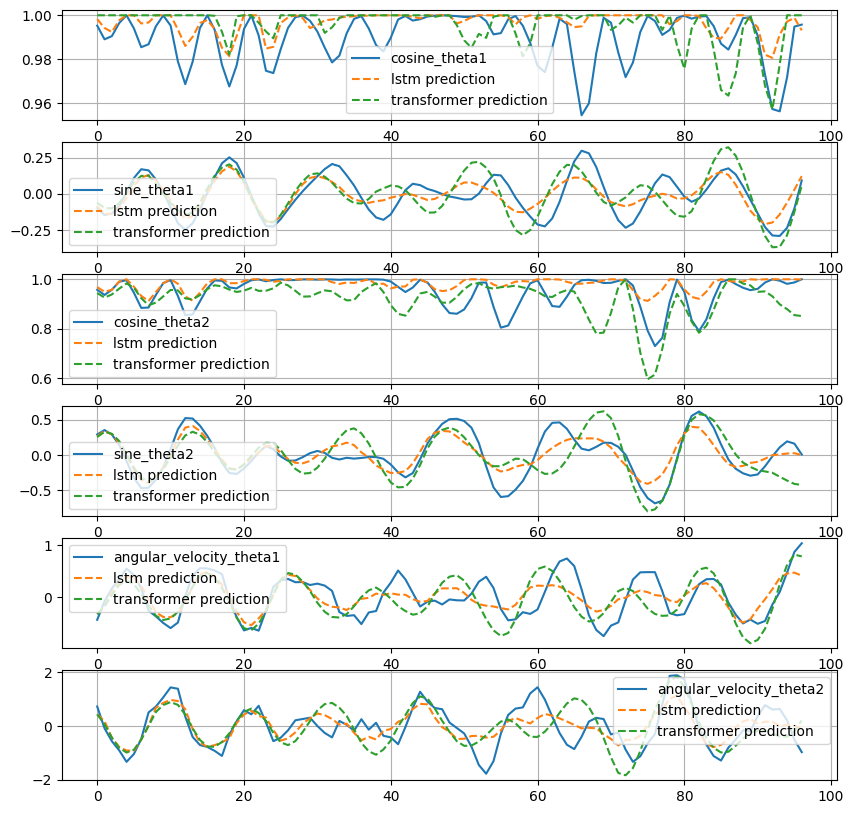

In [41]:
fields = [c for c in target_col if "leg" not in c]
# fields = target_col
fig, axs = plt.subplots (len(fields), 1, figsize=(10,10))


for i in range (len(fields)):
    f = fields[i]
    axs[i].plot(range (len(lstm_dfNet)), dfEval[f].values[window_size:window_size+len(lstm_dfNet)], label=f)
    axs[i].plot(range (len(lstm_dfNet)), lstm_dfNet[f].values, label="lstm prediction", ls="--")
    axs[i].plot(range (len(transformer_dfNet)), transformer_dfNet[f].values, label="transformer prediction", ls="--")
    axs[i].grid()
    axs[i].legend(loc="best")
    
# axs[4].plot(range (len(dfNet)), dfEval[ACTION].values[window_size:window_size+len(dfNet)], label=ACTION)
axs[4].grid()
axs[4].legend(loc="best")

plt.show()


# Calculate Errors

In [42]:
def calculate_mean_error(truth:pd.Series, prediction:pd.Series):
    # remove first window_size elements
    truth = truth[window_size:]
    # remove indices from truth and prediction
    truth = truth.reset_index(drop=True)
    prediction = prediction.reset_index(drop=True)
    
    return np.mean(np.abs(truth - prediction))

In [45]:
num_eval_episodes = 100
dfEval = sample_episodes(num_episodes=num_eval_episodes, max_steps=100)

100%|██████████| 10/10 [00:00<00:00, 140.62it/s]


In [46]:
cosine_theta1_error_lstm = []
cosine_theta1_error_transformer = []
sine_theta1_error_lstm = []
sine_theta1_error_transformer = []
cosine_theta2_error_lstm = []
cosine_theta2_error_transformer = []
sine_theta2_error_lstm = []
sine_theta2_error_transformer = []
angular_velocity_theta1_error_lstm = []
angular_velocity_theta1_error_transformer = []


for df_e in dfEval.groupby("episode"):
    df_e = df_e[1]
    lstm_dfNet = run_model_evaluation(
        model=lstm_model,
        dfEval=df_e,
        input_col=input_col,
        target_col=target_col,
        cols=cols,
        window_size=window_size,
        output_min=output_min,
        output_max=output_max
    )

    transformer_dfNet = run_model_evaluation(
        model=transformer_model,
        dfEval=df_e,
        input_col=input_col,
        target_col=target_col,
        cols=cols,
        window_size=window_size,
        output_min=output_min,
        output_max=output_max
    )

    cosine_theta1_error_lstm.append(calculate_mean_error(df_e["cosine_theta1"], lstm_dfNet["cosine_theta1"]))
    cosine_theta1_error_transformer.append(calculate_mean_error(df_e["cosine_theta1"], transformer_dfNet["cosine_theta1"]))
    sine_theta1_error_lstm.append(calculate_mean_error(df_e["sine_theta1"], lstm_dfNet["sine_theta1"]))
    sine_theta1_error_transformer.append(calculate_mean_error(df_e["sine_theta1"], transformer_dfNet["sine_theta1"]))
    cosine_theta2_error_lstm.append(calculate_mean_error(df_e["cosine_theta2"], lstm_dfNet["cosine_theta2"]))
    cosine_theta2_error_transformer.append(calculate_mean_error(df_e["cosine_theta2"], transformer_dfNet["cosine_theta2"]))
    sine_theta2_error_lstm.append(calculate_mean_error(df_e["sine_theta2"], lstm_dfNet["sine_theta2"]))
    sine_theta2_error_transformer.append(calculate_mean_error(df_e["sine_theta2"], transformer_dfNet["sine_theta2"]))
    angular_velocity_theta1_error_lstm.append(calculate_mean_error(df_e["angular_velocity_theta1"], lstm_dfNet["angular_velocity_theta1"]))
    angular_velocity_theta1_error_transformer.append(calculate_mean_error(df_e["angular_velocity_theta1"], transformer_dfNet["angular_velocity_theta1"]))
    

1/1 [==============================] - 0s 16ms/step


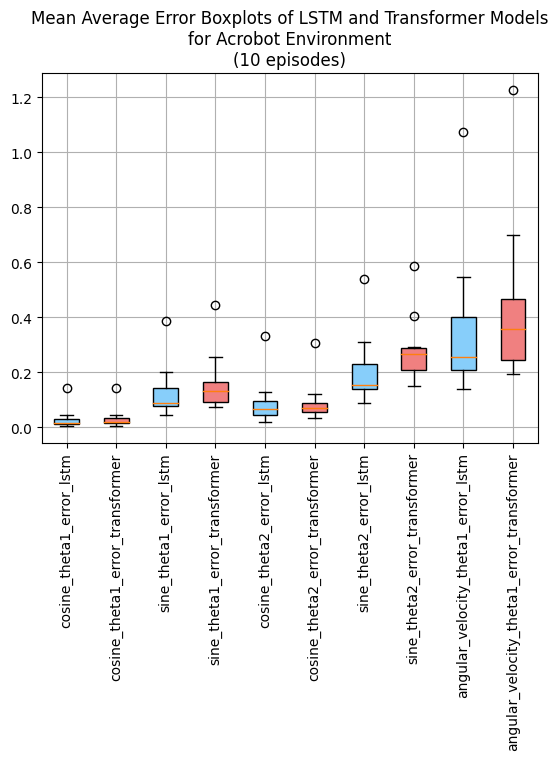

In [48]:
data = [
    cosine_theta1_error_lstm,
    cosine_theta1_error_transformer,
    sine_theta1_error_lstm,
    sine_theta1_error_transformer,
    cosine_theta2_error_lstm,
    cosine_theta2_error_transformer,
    sine_theta2_error_lstm,
    sine_theta2_error_transformer,
    angular_velocity_theta1_error_lstm,
    angular_velocity_theta1_error_transformer
]

labels = [
    "cosine_theta1_error_lstm",
    "cosine_theta1_error_transformer",
    "sine_theta1_error_lstm",
    "sine_theta1_error_transformer",
    "cosine_theta2_error_lstm",
    "cosine_theta2_error_transformer",
    "sine_theta2_error_lstm",
    "sine_theta2_error_transformer",
    "angular_velocity_theta1_error_lstm",
    "angular_velocity_theta1_error_transformer"
]

# Create the boxplot
boxplot = plt.boxplot(data, patch_artist=True, labels=labels)

# Define the colors (alternating colors)
colors = ['lightskyblue', 'lightcoral']

# Color every second box
for i, box in enumerate(boxplot['boxes']):
    box.set_facecolor(colors[i % 2])  # Alternate between two colors

# Add title, grid, and rotate the x-axis labels
plt.title(f"Mean Average Error Boxplots of LSTM and Transformer Models\nfor Acrobot Environment\n({num_eval_episodes} episodes)")
plt.grid()
plt.xticks(rotation=90)

# Show the plot
plt.show()